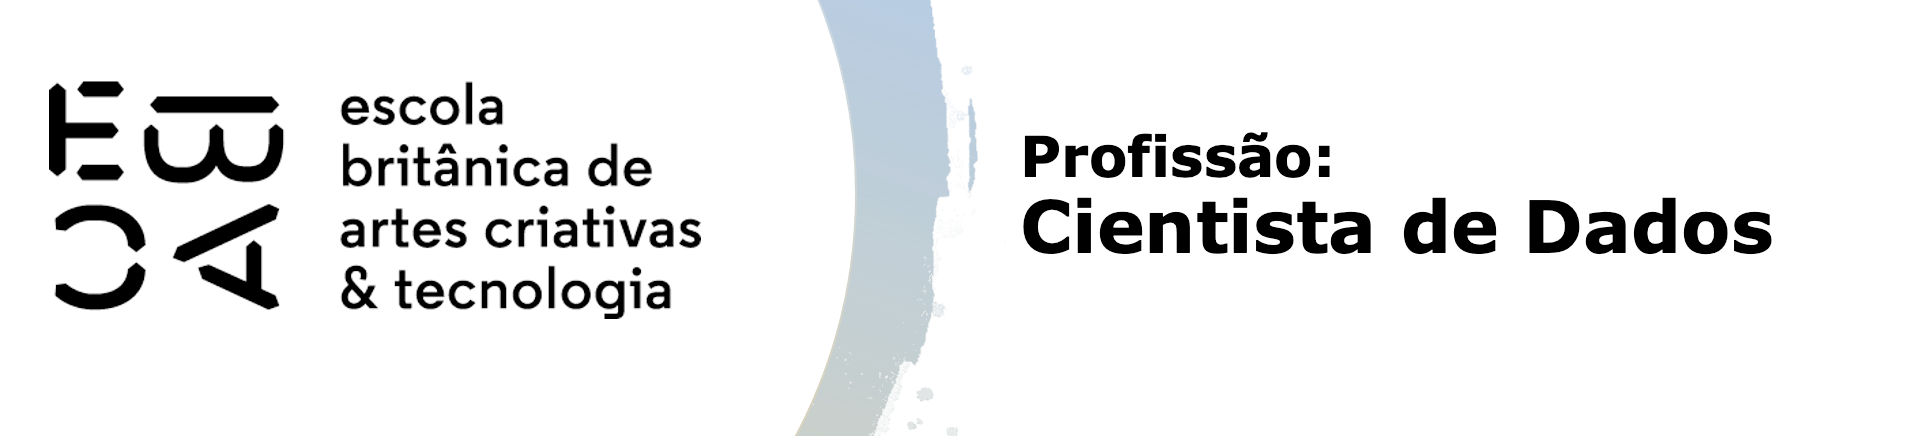

# Task

Based on the task performed in the previous module, we will diagnose the model.

Load the database ```previsao_de_renda2.csv```. Separate into a training base and a test base.

Let's bring back the best version of the model and income forecast you made for this base.

- Replace missings with the average
- Run the model again on the training base (or develop it if you don't have the record saved).

This model must predict the variable ```income``` based on the other variables except ```data_ref``` and ```index```. We have already seen that the income variable is best modeled with the ```log()``` transformation, don't forget that.

In [1]:
########## IMPORTS BLOCK ##########

import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from scipy.stats import kstest
from scipy.interpolate import interp1d
from statsmodels.stats.stattools import durbin_watson
from pandas.core.common import SettingWithCopyWarning
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

warnings.filterwarnings('ignore', category=SettingWithCopyWarning)

In [2]:
########## FILE OPENING ##########

df = pd.read_csv('./previsao_de_renda_II.csv', index_col=0)

########## MISSING VALUES TREATMENT ##########

tempo_emprego_median = df['tempo_emprego'].median()
df['tempo_emprego'].fillna(tempo_emprego_median, inplace=True)

########## TIMEFRAME TREATMENT ##########

df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

########## SEPARATING HOLDOUT SET ##########

date_cut = df.index[-1] - pd.DateOffset(months=3)

train_set = df[df.index < date_cut]
test_set = df[df.index >= date_cut]

########## CATEGORIZING & PROCESSING THE DATA ##########

train_set['Category'] = pd.qcut(train_set['tempo_emprego'], q = 20, duplicates='drop')
test_set['Category'] = pd.qcut(test_set['tempo_emprego'], q = 20, duplicates='drop')

train_set['log_income'] = np.log(train_set['renda'])
test_set['log_income'] = np.log(test_set['renda'])

train_set_grouped = train_set.groupby('Category').agg({'tempo_emprego': ['count', 'mean'],
                                                                'log_income': 'mean'}).reset_index()

test_set_grouped = test_set.groupby('Category').agg({'tempo_emprego': ['count', 'mean'],
                                                              'log_income': 'mean'}).reset_index()

train_set_grouped.columns = ['Category', 'Number_of_observations', 'Avg_Employment_Time', 'Avg_Log_Income']
test_set_grouped.columns = ['Category', 'Number_of_observations', 'Avg_Employment_Time', 'Avg_Log_Income']

train_set = pd.merge(train_set, train_set_grouped, on = 'Category')
test_set = pd.merge(test_set, test_set_grouped, on = 'Category')

########## SEPARATING VARIABLES ##########

X = train_set['Avg_Employment_Time']
y = train_set['Avg_Log_Income'] 

########## LOWESS TECHNIQUE ##########

lowess_model = sm.nonparametric.lowess(y, X)
y_lowess = lowess_model[:, 1]

f = interp1d(lowess_model[:, 0], lowess_model[:, 1], bounds_error = False)

train_set['Lowess'] = f(X)

res_lowess = smf.ols('Avg_Log_Income ~ Lowess', data = train_set).fit()

r_squared_lowess = res_lowess.rsquared_adj * 100
print("- Lowess adjusted-R²: {:.2f} %".format(r_squared_lowess))

- Lowess adjusted-R²: 99.88 %


## Check model assumptions

Do an analysis to evaluate the basic assumptions:

- Do the residuals from this model have a Normal distribution (or something close)?
- Check waste independence
     - Plot residuals versus predicted values
     - Evaluate whether there are patterns of residuals versus each of the model variables
     - Evaluate whether the average value of residuals appears to be related to the reference month
- Evaluate whether the variance of the response variable appears to be in line with the predicted values.

Do you consider that the assumptions are met? Is there any impact on possible deviations?

In [3]:
########## STATISTICAL RESIDUAL DISTRIBUTION ANALYSIS ##########

train_set['Residuals'] = res_lowess.resid

ks_statistic, ks_p_value = kstest(train_set['Residuals'], 'norm')

print("· Kolmogorov-Smirnov stat: {:.2f}".format(ks_statistic))
print("· K-S p-value: {:.1f} %".format(ks_p_value * 100))

alpha = 0.05
if ks_p_value > alpha:
    print("\n The residuals DO follow a Normal Distribution.")
else:
     print("\n The residuals do NOT follow a Normal Distribution.")

dw_stat = durbin_watson(train_set['Residuals'])
print("\n- Durbin-Watson statistic: {:.2f}".format(dw_stat))

· Kolmogorov-Smirnov stat: 0.48
· K-S p-value: 0.0 %

 The residuals do NOT follow a Normal Distribution.

- Durbin-Watson statistic: 0.00


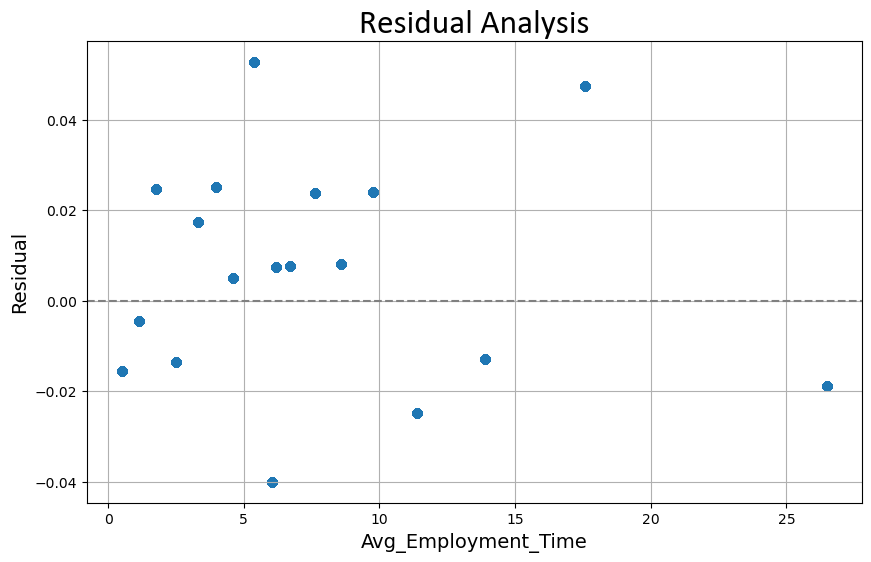

In [4]:
########## RESIDUAL PATTERN ##########

plt.figure(figsize=(10, 6))
plt.scatter(train_set['Avg_Employment_Time'], train_set['Residuals'], alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='--')
plt.title(f'Residual Analysis', fontsize=24, fontname='Calibri')
plt.xlabel('Avg_Employment_Time', fontsize=14)
plt.ylabel('Residual', fontsize=14)
plt.grid(True)
plt.show()

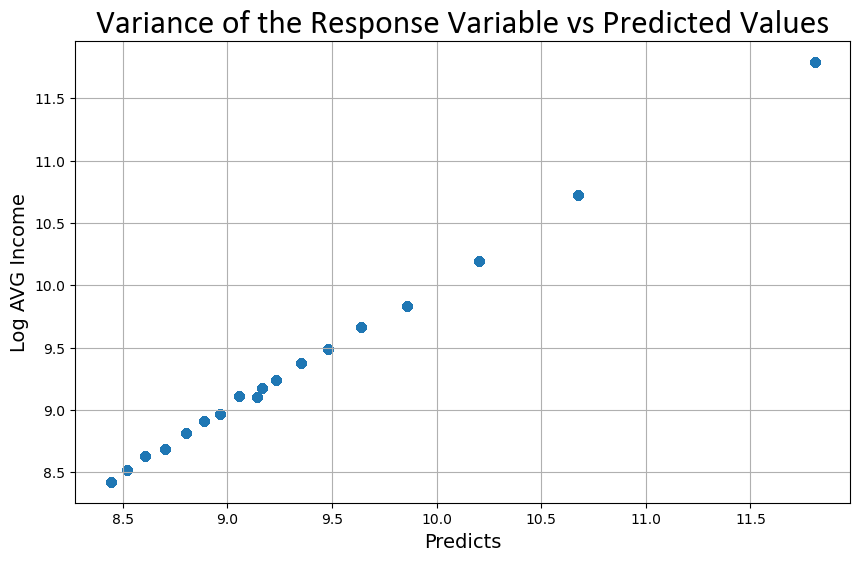

In [5]:
########## TARGET VARIANCE VS PREDICTED VALUES ##########

plt.figure(figsize=(10, 6))
plt.scatter(train_set['Lowess'], train_set['Avg_Log_Income'], alpha=0.5)
plt.title('Variance of the Response Variable vs Predicted Values', fontsize=24, fontname='Calibri')
plt.xlabel('Predicts', fontsize=14)
plt.ylabel('Log AVG Income', fontsize=14)
plt.grid(True)
plt.show()

> The residuals do not follow a strict normal distribution, which can be a problem depending on the sensitivity of the model to the normality of the residuals
> 
> There are no visible patterns in the plots of residuals vs model variables, implying that the relationship is well modeled
>
> The linear dispersion of the predicted values suggests that the variance of the response variable is well adjusted

**Impact of Possible Deviations**:
- Non-normality of residuals can impact the precision of confidence intervals and hypothesis tests
- There are no visual indications of serious problems such as heteroscedasticity or nonlinearity in the residual patterns.

## Outliers

Evaluate the *studentized residuals*, check if there are points that appear to be discrepant.

Assess whether there are influential points.

*Notes*:
- Points with absolute values greater than 2 can be considered as potential outliers.

- The Cook's distance graph shows the influence of each observation on the model parameters. High values indicate observations that may have a disproportionate influence on model results. Observations with values significantly greater than 1 are considered influential. They can have a disproportionate impact on model parameters and should be investigated.

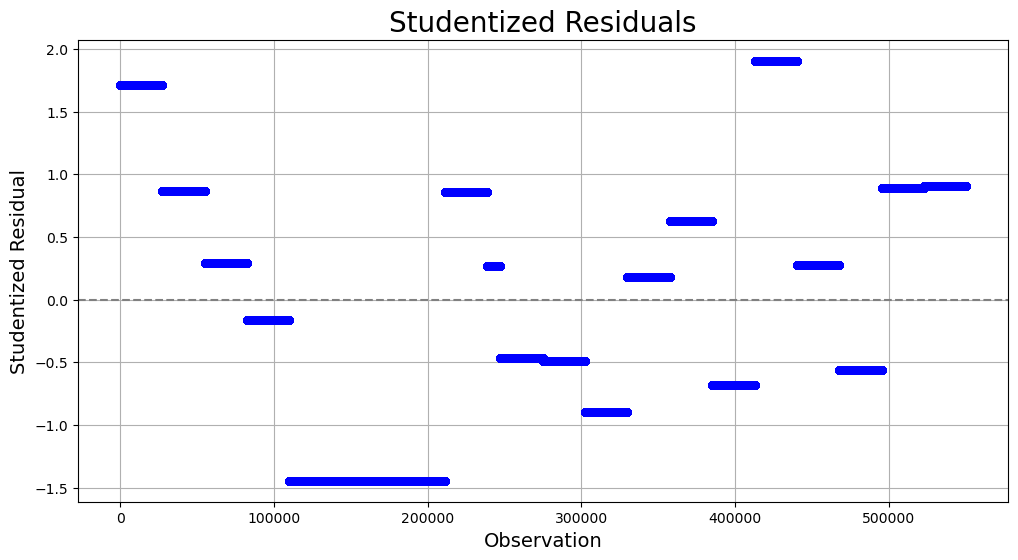

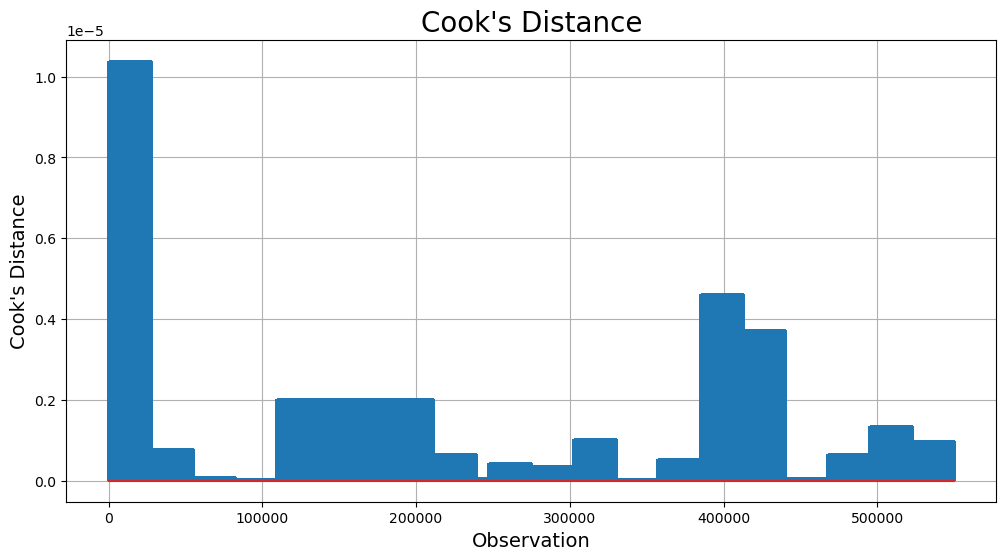

- Total of observations over 1 Cook's Value: 4.55 %


In [6]:
########## STUDENTIZED RESIDUALS & COOK'S DISTANCE ##########

influence = OLSInfluence(res_lowess)
student_resid = influence.resid_studentized_internal
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(12, 6))
plt.plot(student_resid, 'bo', linestyle='none', markersize=5, label='Studentized Residuals')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Studentized Residuals', fontsize=20)
plt.xlabel('Observation', fontsize=14)
plt.ylabel('Studentized Residual', fontsize=14)
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", use_line_collection=True)
plt.title("Cook's Distance", fontsize=20)
plt.xlabel('Observation', fontsize=14)
plt.ylabel("Cook's Distance", fontsize=14)
plt.grid(True)
plt.show()

obs_qtd_percent = (25000/550000) * 100
print("- Total of observations over 1 Cook's Value: {:.2f} %".format(obs_qtd_percent))

> To sum up, the graphical analysis suggests that the data do NOT have extreme outliers in terms of student residuals, and only under 5% of observations can be considered slightly more influential based on Cook's distance.

## Multicollinearity

Assess whether there are issues related to multicollinearity through at least:

- Spearman correlation matrix
- VIF

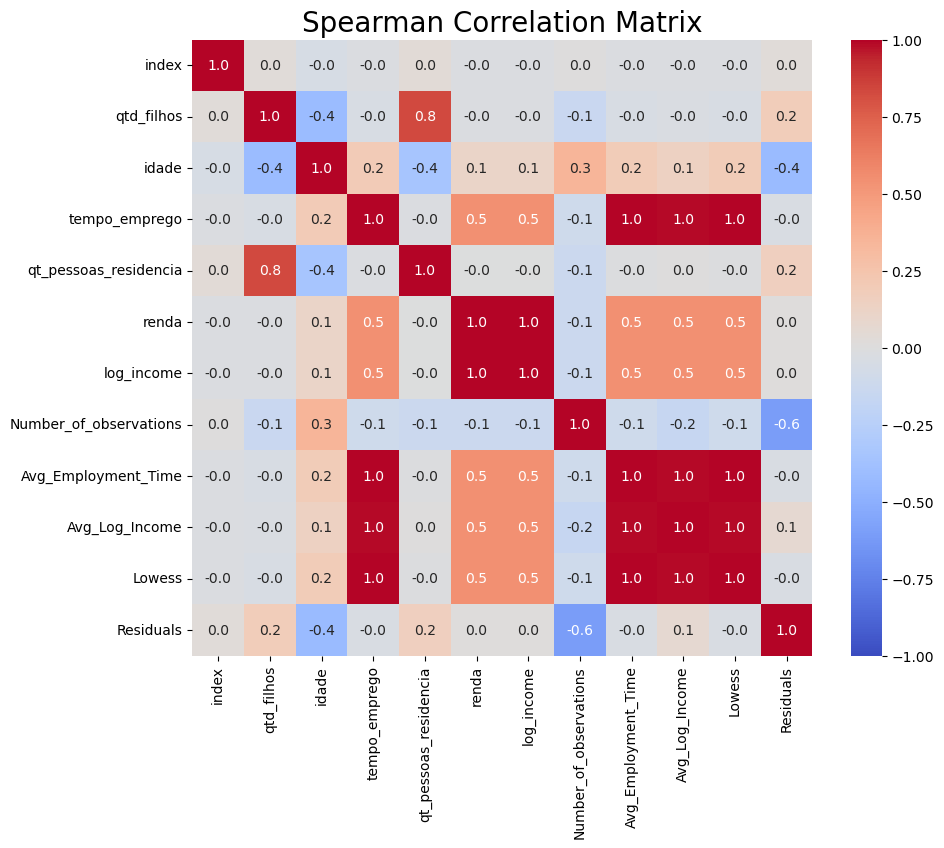

In [10]:
########## SPEARMAN HEATMAP ##########

spearman_corr = train_set.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.1f', vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix', fontsize=20)
plt.show()

In [8]:
########## VIF DATAFRAME ##########

columns_to_exclude = ['Number_of_observations', 'Avg_Employment_Time', 'Avg_Log_Income', 'Lowess', 'Residuals']
numerical_columns = [col for col in train_set.select_dtypes(include=['float64', 'int64']).columns
                     if col not in columns_to_exclude]

X_multi = train_set[numerical_columns]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_multi.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi.values, i) for i in range(len(X_multi.columns))]

pd.options.display.float_format = '{:.0f}'.format
vif_data.set_index('Feature', inplace=True)
vif_data

,VIF
Feature,
index,4
qtd_filhos,6
idade,17
tempo_emprego,4
qt_pessoas_residencia,29
renda,1
log_income,37


- Based on the calculated VIFs values:

> Variables as 'idade', 'qt_pessoas_residencia' and 'log_income' show higher VIFs (> 10), which suggests the presence of significant multicollinearity between them and other variables in the model.

## Settings

Make any adjustments you deem necessary to the model and compare the performance metrics of the original and adjusted models on the test base.

In [9]:
########## CONFIGURATING & COMPARING ##########

test_set['Lowess'] = f(test_set['Avg_Employment_Time'])

test_set['Adjusted_Predictions'] = res_lowess.predict(test_set)

r2_adjusted = r2_score(test_set['Avg_Log_Income'], test_set['Adjusted_Predictions']) * 100
rmse_adjusted = np.sqrt(mean_squared_error(test_set['Avg_Log_Income'], test_set['Adjusted_Predictions']))
mae_adjusted = mean_absolute_error(test_set['Avg_Log_Income'], test_set['Adjusted_Predictions'])

print("Test Set Model Metrics:")
print(f"R-squared: {r2_adjusted:.2f} %")
print(f"RMSE: {rmse_adjusted:.2f}")
print(f"MAE: {mae_adjusted:.2f}")

Test Set Model Metrics:
R-squared: -102.33 %
RMSE: 1.11
MAE: 1.11
